# COMP5329 Deep Learning — Assignment 2
## Depth vs. Width Trade-off in CNNs on CIFAR-100

See `PROJECT_PLAN.md` for the full methodology.

### Project file structure
```
COMP5329_Deep_Learning_As2/
├── config.py             ← all hyperparameters (single source of truth)
├── models/
│   └── cnn_family.py     ← 6-model VGG-style architecture family (Phase 1)
├── utils/
│   ├── data.py           ← CIFAR-100 DataLoaders
│   ├── train.py          ← training loop, checkpointing, gradient logging
│   ├── evaluate.py       ← per-class and per-tier accuracy
│   └── complexity.py     ← image complexity scoring (Phase 3)
└── main.ipynb            ← this notebook (orchestrator only)
```

> **In Colab:** after any change to a `.py` file in Drive, re-run the
> *Setup* cell and the *Reload modules* cell — no runtime restart needed.

---
## 0. Setup

In [1]:
# ── Mount Drive and add project root to Python path ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys
import os

PROJECT_ROOT = '/content/drive/MyDrive/COMP5329_Deep_Learning_As2'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('Drive mounted.')
print(f'Project root on path: {PROJECT_ROOT}')

Mounted at /content/drive
Drive mounted.
Project root on path: /content/drive/MyDrive/COMP5329_Deep_Learning_As2


In [2]:
# ── Standard imports + device ─────────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import gc
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU — training will be very slow.')

Device: cuda
GPU:  NVIDIA L4
VRAM: 23.7 GB


In [3]:
# ── Load project modules ──────────────────────────────────────────────────────
# Re-run this cell after editing any .py file in Drive.
import config
import utils.data     as data_mod
import utils.train    as train_mod
import utils.evaluate as eval_mod
import utils.complexity as complexity_mod

importlib.reload(config)
importlib.reload(data_mod)
importlib.reload(train_mod)
importlib.reload(eval_mod)
importlib.reload(complexity_mod)

from config import CFG
from utils.train    import train_model, count_params, check_budget
from utils.evaluate import per_class_accuracy, per_tier_accuracy

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print('Modules loaded. Seed:', CFG['seed'])
print(f"Parameter budget: {CFG['param_budget']:,} +/- {CFG['param_tol']*100:.0f}%")

Modules loaded. Seed: 42
Parameter budget: 1,500,000 +/- 5%


In [4]:
# ── CIFAR-100 DataLoaders ─────────────────────────────────────────────────────
from utils.data import get_cifar100_loaders

train_loader, test_loader = get_cifar100_loaders(CFG['batch_size'], CFG['data_dir'])

_imgs, _lbls = next(iter(train_loader))
print(f'Batch: {tuple(_imgs.shape)}  |  Labels: {tuple(_lbls.shape)}')
assert _imgs.shape == (CFG['batch_size'], 3, 32, 32)
print('Data pipeline OK.')

100%|██████████| 169M/169M [03:09<00:00, 891kB/s]


Train: 50,000 images | Test: 10,000 images
Classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver'] ... (100 total)
Batch: (256, 3, 32, 32)  |  Labels: (256,)
Data pipeline OK.


---
## 1. Architecture Family (Phase 1)

Six VGG-style CNNs spanning depth vs. width, all ~1.5 M parameters.
Implementation lives in `models/cnn_family.py`.

In [5]:
# ── Phase 1: Build and verify the model family ───────────────────────────────
import models.cnn_family as cnn_mod
importlib.reload(cnn_mod)

from models.cnn_family import build_model_family, MODEL_CONFIGS

# Instantiate all 6 models
model_family = build_model_family(num_classes=CFG['num_classes'])

# ── Parameter budget table ──
budget = CFG['param_budget']
lo, hi = budget * (1 - CFG['param_tol']), budget * (1 + CFG['param_tol'])

print(f"{'Model':<6}  {'Depth':>5}  {'Width':>5}  {'Params':>10}  {'Delta':>8}  {'Status':<6}  Stages")
print('-' * 66)
all_ok = True
for name, model in model_family.items():
    n   = count_params(model)
    d   = MODEL_CONFIGS[name]['depth']
    w   = MODEL_CONFIGS[name]['width']
    pct = 100 * (n - budget) / budget
    ok  = lo <= n <= hi
    all_ok = all_ok and ok
    print(f"{name:<6}  {d:>5}  {w:>5}  {n:>10,}  {pct:>+7.2f}%  {'OK' if ok else 'FAIL':<6}  {model.stage_depths}")

print()
print('All models within budget.' if all_ok else 'WARNING: budget violation in one or more models.')

# ── Forward pass sanity check ──
print(f'\nForward pass check (batch 4 x 3 x 32 x 32):')
_dummy = torch.randn(4, 3, 32, 32)
for name, model in model_family.items():
    out = model(_dummy)
    assert out.shape == (4, CFG['num_classes']), f'{name}: unexpected output shape {out.shape}'
    print(f'  {name}  -> {tuple(out.shape)}  OK')

print('\n>>> Phase 1 complete — architecture family ready. <<<')

Model   Depth  Width      Params     Delta  Status  Stages
------------------------------------------------------------------
M1          4    233   1,497,358    -0.18%  OK      (1, 1, 2)
M2          8    153   1,496,746    -0.22%  OK      (2, 2, 4)
M3         12    122   1,492,038    -0.53%  OK      (4, 4, 4)
M4         16    105   1,505,170    +0.34%  OK      (5, 5, 6)
M5         20     93   1,494,610    -0.36%  OK      (6, 6, 8)
M6         28     78   1,492,786    -0.48%  OK      (9, 9, 10)

All models within budget.

Forward pass check (batch 4 x 3 x 32 x 32):
  M1  -> (4, 100)  OK
  M2  -> (4, 100)  OK
  M3  -> (4, 100)  OK
  M4  -> (4, 100)  OK
  M5  -> (4, 100)  OK
  M6  -> (4, 100)  OK

>>> Phase 1 complete — architecture family ready. <<<


---
## 2. Training (Phase 2)

Train all 6 models sequentially with identical hyperparameters.
Each run saves a checkpoint and logs to Drive automatically.

In [6]:
# ── Phase 2 status overview ───────────────────────────────────────────────────
# Run this cell any time to see which models are done / pending / partial.
from utils.train import is_training_complete
import os

print(f"{'Model':<6}  {'Status':<10}  {'Best ckpt':<8}  {'Log rows':>8}")
print('-' * 46)
for name in model_family:
    done     = is_training_complete(name, CFG)
    has_best = os.path.exists(os.path.join(CFG['drive_base'], 'checkpoints', f'{name}_best.pth'))
    log_path = os.path.join(CFG['drive_base'], 'logs', f'{name}_log.csv')
    rows     = len(pd.read_csv(log_path)) if os.path.exists(log_path) else 0
    status   = 'DONE' if done else ('partial' if rows > 0 else 'pending')
    print(f"{name:<6}  {status:<10}  {'yes' if has_best else 'no':<8}  {rows:>8}/{CFG['epochs']}")

Model   Status      Best ckpt  Log rows
----------------------------------------------
M1      DONE        yes            200/200
M2      DONE        yes            200/200
M3      DONE        yes            200/200
M4      DONE        yes            200/200
M5      DONE        yes            200/200
M6      DONE        yes            200/200


In [ ]:
# ── M1: depth=4, width=233  (very shallow, very wide) ────────────────────────
RESUME = False   # True = resume from last checkpoint | False = train from scratch

name  = 'M1'
model = model_family[name]

log_M1, best_M1 = train_model(
    model, name, train_loader, test_loader, device, CFG,
    resume=RESUME, log_every=10, ckpt_every=50,
)
model.cpu(); gc.collect(); torch.cuda.empty_cache()
print(f'\nM1 done.  Best val acc: {best_M1:.2f}%')

In [ ]:
# ── M2: depth=8, width=153  (shallow, wide) ──────────────────────────────────
RESUME = False   # True = resume from last checkpoint | False = train from scratch

name  = 'M2'
model = model_family[name]

log_M2, best_M2 = train_model(
    model, name, train_loader, test_loader, device, CFG,
    resume=RESUME, log_every=10, ckpt_every=50,
)
model.cpu(); gc.collect(); torch.cuda.empty_cache()
print(f'\nM2 done.  Best val acc: {best_M2:.2f}%')

In [ ]:
# ── M3: depth=12, width=122  (medium balanced) ───────────────────────────────
RESUME = False   # True = resume from last checkpoint | False = train from scratch

name  = 'M3'
model = model_family[name]

log_M3, best_M3 = train_model(
    model, name, train_loader, test_loader, device, CFG,
    resume=RESUME, log_every=10, ckpt_every=50,
)
model.cpu(); gc.collect(); torch.cuda.empty_cache()
print(f'\nM3 done.  Best val acc: {best_M3:.2f}%')

In [ ]:
# ── M4: depth=16, width=105  (deep, narrow) ──────────────────────────────────
RESUME = False   # True = resume from last checkpoint | False = train from scratch

name  = 'M4'
model = model_family[name]

log_M4, best_M4 = train_model(
    model, name, train_loader, test_loader, device, CFG,
    resume=RESUME, log_every=10, ckpt_every=50,
)
model.cpu(); gc.collect(); torch.cuda.empty_cache()
print(f'\nM4 done.  Best val acc: {best_M4:.2f}%')

In [ ]:
# ── M5: depth=20, width=93  (very deep, narrow) ──────────────────────────────
RESUME = False   # True = resume from last checkpoint | False = train from scratch

name  = 'M5'
model = model_family[name]

log_M5, best_M5 = train_model(
    model, name, train_loader, test_loader, device, CFG,
    resume=RESUME, log_every=10, ckpt_every=50,
)
model.cpu(); gc.collect(); torch.cuda.empty_cache()
print(f'\nM5 done.  Best val acc: {best_M5:.2f}%')

In [ ]:
# ── M6: depth=28, width=78  (extremely deep, very narrow) ────────────────────
RESUME = False   # True = resume from last checkpoint | False = train from scratch

name  = 'M6'
model = model_family[name]

log_M6, best_M6 = train_model(
    model, name, train_loader, test_loader, device, CFG,
    resume=RESUME, log_every=10, ckpt_every=50,
)
model.cpu(); gc.collect(); torch.cuda.empty_cache()
print(f'\nM6 done.  Best val acc: {best_M6:.2f}%')

---
## 3. Image Complexity Scoring (Phase 3)

Score each test image by Laplacian variance, stratify into 3 tiers,
then compute per-tier accuracy for each trained model.

In [7]:
# ── Phase 3: Image Complexity Scoring + Superclass Analysis ──────────────────
import json
from utils.data       import get_test_dataset
from utils.complexity import score_dataset, stratify, tier_summary
from utils.evaluate   import (load_best_checkpoint, per_tier_accuracy,
                               per_superclass_accuracy, per_class_accuracy,
                               build_class_to_superclass, CIFAR100_SUPERCLASSES)

MODEL_NAMES  = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']
TIER_NAMES   = ['Low', 'Medium', 'High']
RESULTS_PATH = os.path.join(CFG['drive_base'], 'logs', 'phase3_results.json')

# ── Step 1: Image complexity scoring ──
print('Step 1: Scoring test images by Laplacian variance...')
raw_test    = get_test_dataset(CFG['data_dir'])
scores      = score_dataset(raw_test)
tier_labels = stratify(scores, n_tiers=3)
tier_summary(scores, tier_labels)

# Build superclass lookup from the dataset class list
class_to_superclass = build_class_to_superclass(raw_test.classes)

# ── Step 2: Evaluate all models ──
print('\nStep 2: Evaluating all 6 models on best checkpoints...')
results = {}

for name in MODEL_NAMES:
    model = model_family[name]
    val_acc = load_best_checkpoint(model, name, CFG, device)
    print(f'\n  {name}  (best val acc: {val_acc:.2f}%)')

    # Per-tier accuracy
    tier_acc = per_tier_accuracy(model, test_loader, device, tier_labels)

    # Per-superclass accuracy
    sup_acc  = per_superclass_accuracy(model, test_loader, device, class_to_superclass)

    results[name] = {
        'best_val_acc':       val_acc,
        'tier_accuracy':      {TIER_NAMES[k]: round(v, 2) for k, v in tier_acc.items()},
        'superclass_accuracy': {k: round(v, 2) for k, v in sup_acc.items()},
    }
    print(f'    Tier acc  — Low: {tier_acc[0]:.1f}%  Med: {tier_acc[1]:.1f}%  High: {tier_acc[2]:.1f}%')

    model.cpu()

# ── Step 3: Print summary tables ──
print('\n\n' + '='*60)
print('  Per-Complexity-Tier Accuracy')
print('='*60)
print(f"{'Model':<6}  {'Overall':>8}  {'Low':>8}  {'Medium':>8}  {'High':>8}")
print('-'*50)
for name in MODEL_NAMES:
    r = results[name]
    t = r['tier_accuracy']
    print(f"{name:<6}  {r['best_val_acc']:>8.2f}%  "
          f"{t['Low']:>7.2f}%  {t['Medium']:>8.2f}%  {t['High']:>8.2f}%")

print('\n' + '='*60)
print('  Per-Superclass Accuracy (best deep vs best wide)')
print('='*60)
# Compare M1 (widest) vs M3 (best) vs M6 (deepest)
compare = ['M1', 'M3', 'M6']
print(f"{'Superclass':<32}  " + '  '.join(f'{m:>7}' for m in compare))
print('-' * 60)
for sup in sorted(CIFAR100_SUPERCLASSES.keys()):
    row = '  '.join(f"{results[m]['superclass_accuracy'].get(sup, 0):>7.1f}%" for m in compare)
    print(f"{sup:<32}  {row}")

# ── Step 4: Save results to Drive ──
with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResults saved to: {RESULTS_PATH}')
print('\n>>> Phase 3 complete. <<<')

Step 1: Scoring test images by Laplacian variance...
  Scored 0/10000 images...
  Scored 2000/10000 images...
  Scored 4000/10000 images...
  Scored 6000/10000 images...
  Scored 8000/10000 images...
  Done. Score range: [19.73, 16240.61]

Tier       Name          Count Score range
---------------------------------------------
0          Low            3334   [19.73, 1514.65]
1          Medium         3333   [1515.20, 2672.46]
2          High           3333   [2672.85, 16240.61]

Step 2: Evaluating all 6 models on best checkpoints...

  M1  (best val acc: 67.54%)
    Tier acc  — Low: 67.5%  Med: 66.5%  High: 68.6%

  M2  (best val acc: 72.50%)
    Tier acc  — Low: 72.0%  Med: 71.8%  High: 73.6%

  M3  (best val acc: 74.01%)
    Tier acc  — Low: 73.3%  Med: 73.2%  High: 75.5%

  M4  (best val acc: 73.69%)
    Tier acc  — Low: 73.3%  Med: 72.8%  High: 75.0%

  M5  (best val acc: 73.54%)
    Tier acc  — Low: 73.6%  Med: 72.6%  High: 74.4%

  M6  (best val acc: 71.51%)
    Tier acc  — Low:

---
## 4. Analysis & Visualisation (Phase 4)

In [8]:
# ── Phase 4: Load all data ────────────────────────────────────────────────────
import json, re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from models.cnn_family import MODEL_CONFIGS, _split_depth

MODEL_NAMES = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']
META = {n: {**MODEL_CONFIGS[n], 'stage_depths': _split_depth(MODEL_CONFIGS[n]['depth'])}
        for n in MODEL_NAMES}

FIGS_DIR  = os.path.join(CFG['drive_base'], 'figures')
LOGS_DIR  = os.path.join(CFG['drive_base'], 'logs')
os.makedirs(FIGS_DIR, exist_ok=True)

# Training logs
logs = {n: pd.read_csv(os.path.join(LOGS_DIR, f'{n}_log.csv')) for n in MODEL_NAMES}

# Phase 3 results
with open(os.path.join(LOGS_DIR, 'phase3_results.json')) as f:
    phase3 = json.load(f)

# Consistent color scheme: blue (shallow/wide) → red (deep/narrow)
COLORS = {n: c for n, c in zip(MODEL_NAMES, plt.cm.coolwarm(np.linspace(0.05, 0.95, 6)))}

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
print('Data loaded. Figures will be saved to:', FIGS_DIR)

Data loaded. Figures will be saved to: /content/drive/MyDrive/COMP5329_Deep_Learning_As2/figures


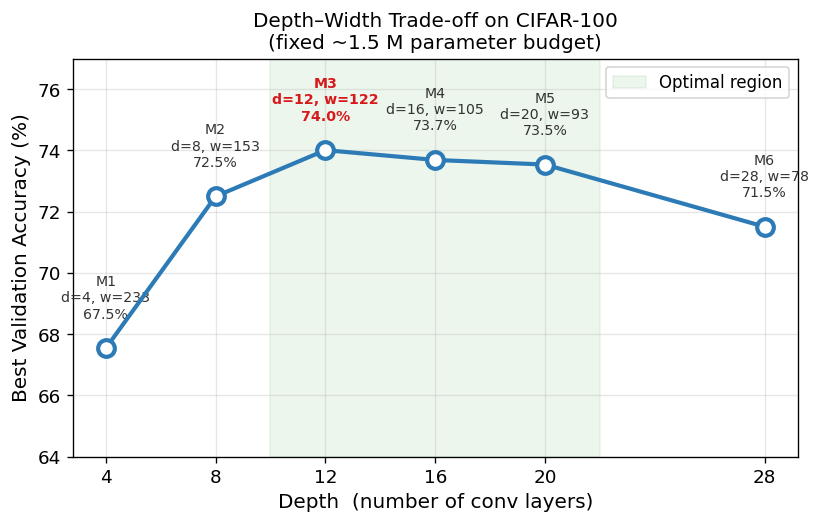

Saved: /content/drive/MyDrive/COMP5329_Deep_Learning_As2/figures/fig1_accuracy_vs_depth.pdf


In [9]:
# ── Figure 1: Accuracy vs. Depth (main result) ───────────────────────────────
depths   = [META[n]['depth']        for n in MODEL_NAMES]
widths   = [META[n]['width']        for n in MODEL_NAMES]
best_acc = [phase3[n]['best_val_acc'] for n in MODEL_NAMES]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(depths, best_acc, 'o-', color='#2c7bb6', linewidth=2.5,
        markersize=10, markerfacecolor='white', markeredgewidth=2.5, zorder=4)

for n, d, w, a in zip(MODEL_NAMES, depths, widths, best_acc):
    is_best = (a == max(best_acc))
    ax.annotate(
        f'{n}\nd={d}, w={w}\n{a:.1f}%',
        xy=(d, a), xytext=(0, 18), textcoords='offset points',
        ha='center', fontsize=8.5,
        color='#d7191c' if is_best else '#333333',
        fontweight='bold' if is_best else 'normal',
    )

# Shade the plateau region
ax.axvspan(10, 22, alpha=0.07, color='green', label='Optimal region')

ax.set_xlabel('Depth  (number of conv layers)', fontsize=12)
ax.set_ylabel('Best Validation Accuracy (%)', fontsize=12)
ax.set_title('Depth–Width Trade-off on CIFAR-100\n(fixed ~1.5 M parameter budget)', fontsize=12)
ax.set_xticks(depths)
ax.set_ylim(64, 77)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(FIGS_DIR, 'fig1_accuracy_vs_depth.pdf')
plt.savefig(path, bbox_inches='tight')
plt.savefig(path.replace('.pdf', '.png'), bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

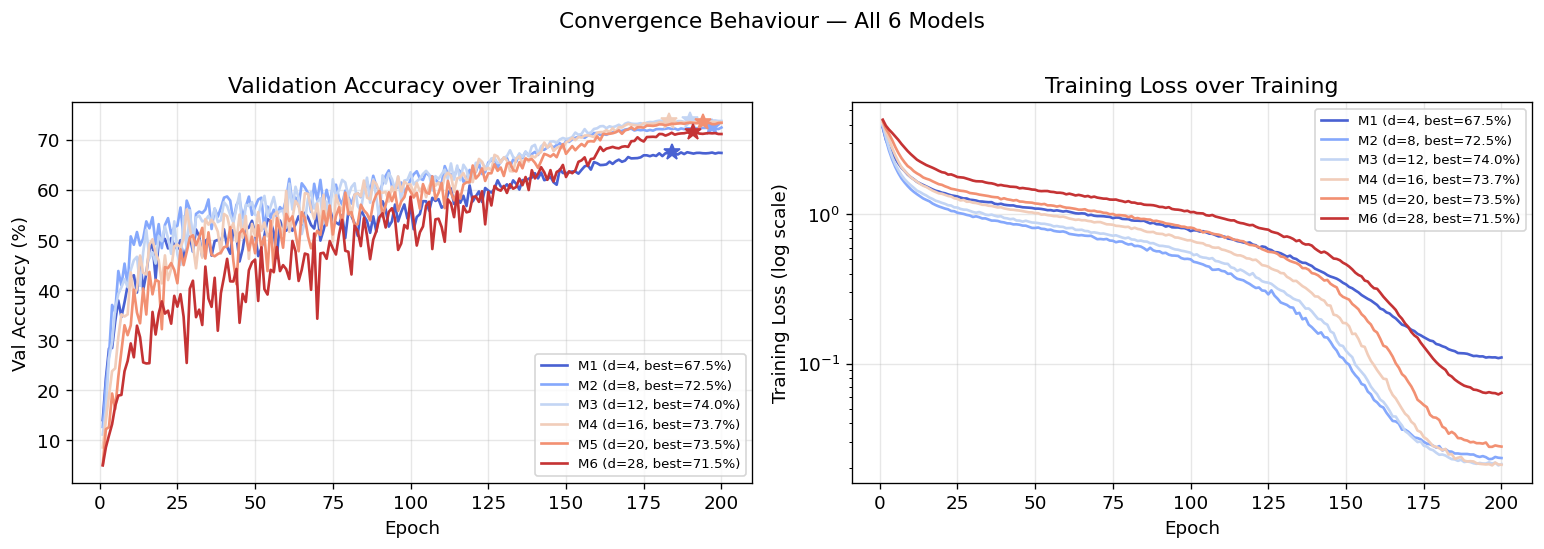

Saved: /content/drive/MyDrive/COMP5329_Deep_Learning_As2/figures/fig2_convergence.pdf


In [10]:
# ── Figure 2: Convergence curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for n in MODEL_NAMES:
    df    = logs[n]
    color = COLORS[n]
    label = f"{n} (d={META[n]['depth']}, best={phase3[n]['best_val_acc']:.1f}%)"

    # Left: validation accuracy
    axes[0].plot(df['epoch'], df['val_acc1'], color=color, linewidth=1.6, label=label)
    best_ep = df.loc[df['val_acc1'].idxmax(), 'epoch']
    axes[0].plot(best_ep, phase3[n]['best_val_acc'], '*', color=color, markersize=10)

    # Right: training loss (log scale shows convergence speed)
    axes[1].plot(df['epoch'], df['tr_loss'], color=color, linewidth=1.6, label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Accuracy (%)')
axes[0].set_title('Validation Accuracy over Training')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Training Loss (log scale)')
axes[1].set_title('Training Loss over Training')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Convergence Behaviour — All 6 Models', fontsize=13, y=1.01)
plt.tight_layout()
path = os.path.join(FIGS_DIR, 'fig2_convergence.pdf')
plt.savefig(path, bbox_inches='tight')
plt.savefig(path.replace('.pdf', '.png'), bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

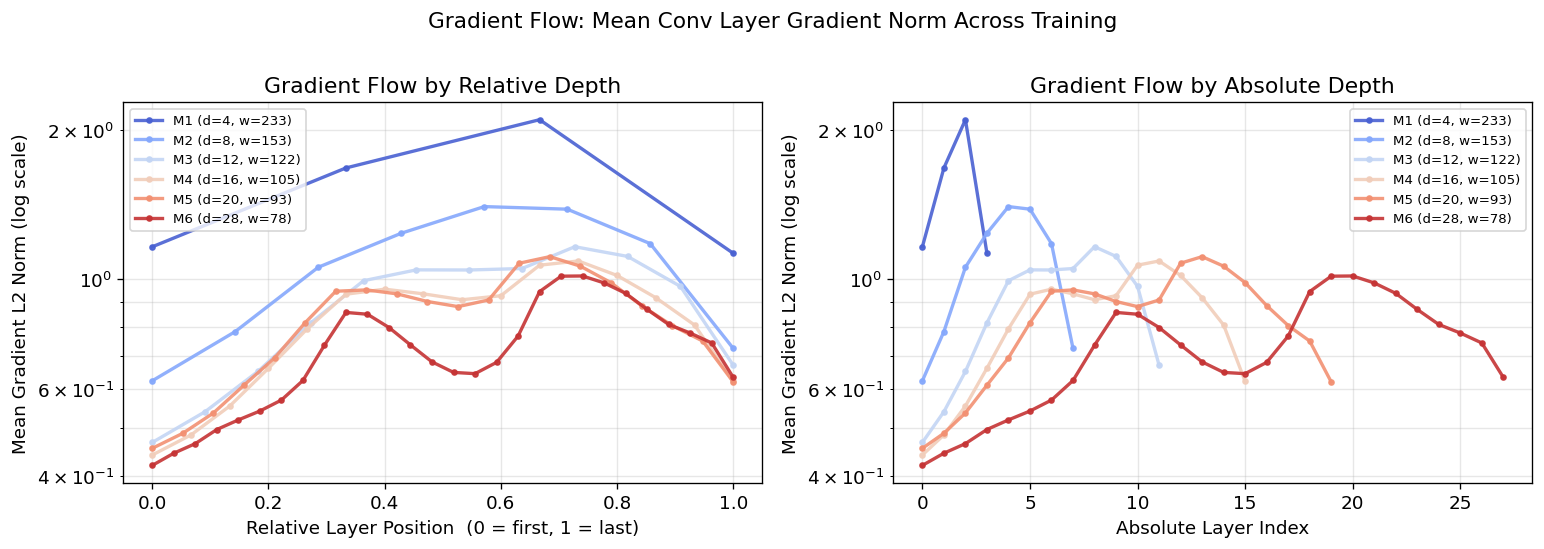

Saved: /content/drive/MyDrive/COMP5329_Deep_Learning_As2/figures/fig3_gradient_flow.pdf


In [11]:
# ── Figure 3: Gradient Flow ───────────────────────────────────────────────────
def load_mean_grad_norms(model_name: str, stage_depths: tuple) -> tuple:
    """
    Load gradnorms JSON, average conv.weight norms across all epochs,
    return (relative_positions, mean_norms) in layer-depth order.
    """
    d1, d2, d3 = stage_depths
    total = d1 + d2 + d3

    def layer_index(key):
        s = int(re.search(r'stage(\d)', key).group(1))
        l = int(re.search(r'layers\.(\d+)', key).group(1))
        return [0, d1, d1 + d2][s - 1] + l

    path = os.path.join(LOGS_DIR, f'{model_name}_gradnorms.json')
    with open(path) as f:
        glog = json.load(f)

    sums, count = {}, len(glog)
    for entry in glog:
        for k, v in entry['grad_norms'].items():
            if '.conv.weight' in k:
                sums[k] = sums.get(k, 0.0) + v

    avgs = {k: v / count for k, v in sums.items()}
    ordered = sorted(avgs.items(), key=lambda x: layer_index(x[0]))

    indices = [layer_index(k) for k, _ in ordered]
    norms   = [v for _, v in ordered]
    rel_pos = [i / (total - 1) for i in indices]
    return rel_pos, norms, indices


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for n in MODEL_NAMES:
    rel_pos, norms, indices = load_mean_grad_norms(n, META[n]['stage_depths'])
    color = COLORS[n]
    label = f"{n} (d={META[n]['depth']}, w={META[n]['width']})"

    # Left: gradient norm vs relative depth position
    axes[0].plot(rel_pos, norms, color=color, linewidth=2, label=label,
                 marker='o', markersize=3, alpha=0.9)

    # Right: gradient norm vs absolute layer index
    axes[1].plot(indices, norms, color=color, linewidth=2, label=label,
                 marker='o', markersize=3, alpha=0.9)

for ax in axes:
    ax.set_yscale('log')
    ax.set_ylabel('Mean Gradient L2 Norm (log scale)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

axes[0].set_xlabel('Relative Layer Position  (0 = first, 1 = last)')
axes[0].set_title('Gradient Flow by Relative Depth')

axes[1].set_xlabel('Absolute Layer Index')
axes[1].set_title('Gradient Flow by Absolute Depth')

plt.suptitle('Gradient Flow: Mean Conv Layer Gradient Norm Across Training', fontsize=13, y=1.01)
plt.tight_layout()
path = os.path.join(FIGS_DIR, 'fig3_gradient_flow.pdf')
plt.savefig(path, bbox_inches='tight')
plt.savefig(path.replace('.pdf', '.png'), bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

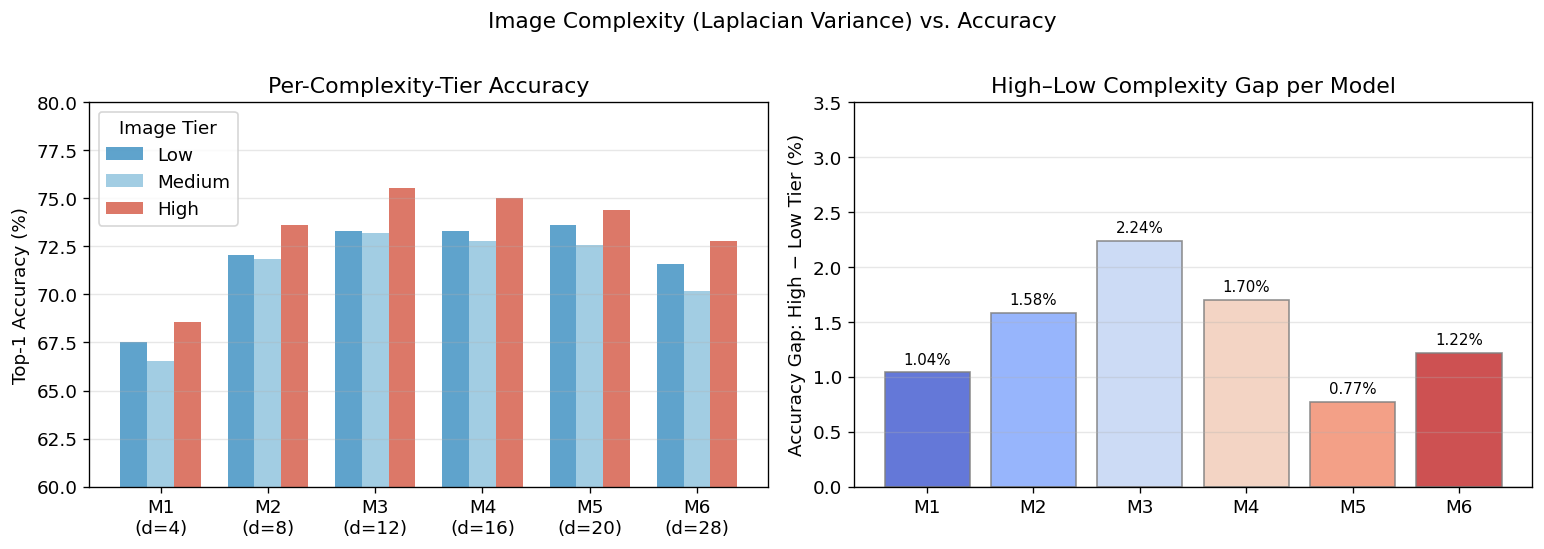

Saved: /content/drive/MyDrive/COMP5329_Deep_Learning_As2/figures/fig4_complexity_tiers.pdf


In [12]:
# ── Figure 4: Complexity Tier Accuracy ───────────────────────────────────────
TIER_NAMES   = ['Low', 'Medium', 'High']
TIER_COLORS  = ['#4393c3', '#92c5de', '#d6604d']
x     = np.arange(len(MODEL_NAMES))
w     = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: grouped bar chart
for j, (tier, tc) in enumerate(zip(TIER_NAMES, TIER_COLORS)):
    vals = [phase3[n]['tier_accuracy'][tier] for n in MODEL_NAMES]
    bars = axes[0].bar(x + (j - 1) * w, vals, w, label=tier, color=tc, alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{n}\n(d={META[n]['depth']})" for n in MODEL_NAMES])
axes[0].set_ylabel('Top-1 Accuracy (%)')
axes[0].set_title('Per-Complexity-Tier Accuracy')
axes[0].legend(title='Image Tier')
axes[0].set_ylim(60, 80)
axes[0].grid(True, alpha=0.3, axis='y')

# Right: line plot of tier spread (High - Low) per model
spread = [phase3[n]['tier_accuracy']['High'] - phase3[n]['tier_accuracy']['Low']
          for n in MODEL_NAMES]
depths_list = [META[n]['depth'] for n in MODEL_NAMES]
axes[1].bar(MODEL_NAMES, spread,
            color=[COLORS[n] for n in MODEL_NAMES], alpha=0.85, edgecolor='grey')
axes[1].set_ylabel('Accuracy Gap: High − Low Tier (%)')
axes[1].set_title('High–Low Complexity Gap per Model')
axes[1].set_ylim(0, 3.5)
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(axes[1].patches, spread)):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Image Complexity (Laplacian Variance) vs. Accuracy', fontsize=13, y=1.01)
plt.tight_layout()
path = os.path.join(FIGS_DIR, 'fig4_complexity_tiers.pdf')
plt.savefig(path, bbox_inches='tight')
plt.savefig(path.replace('.pdf', '.png'), bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

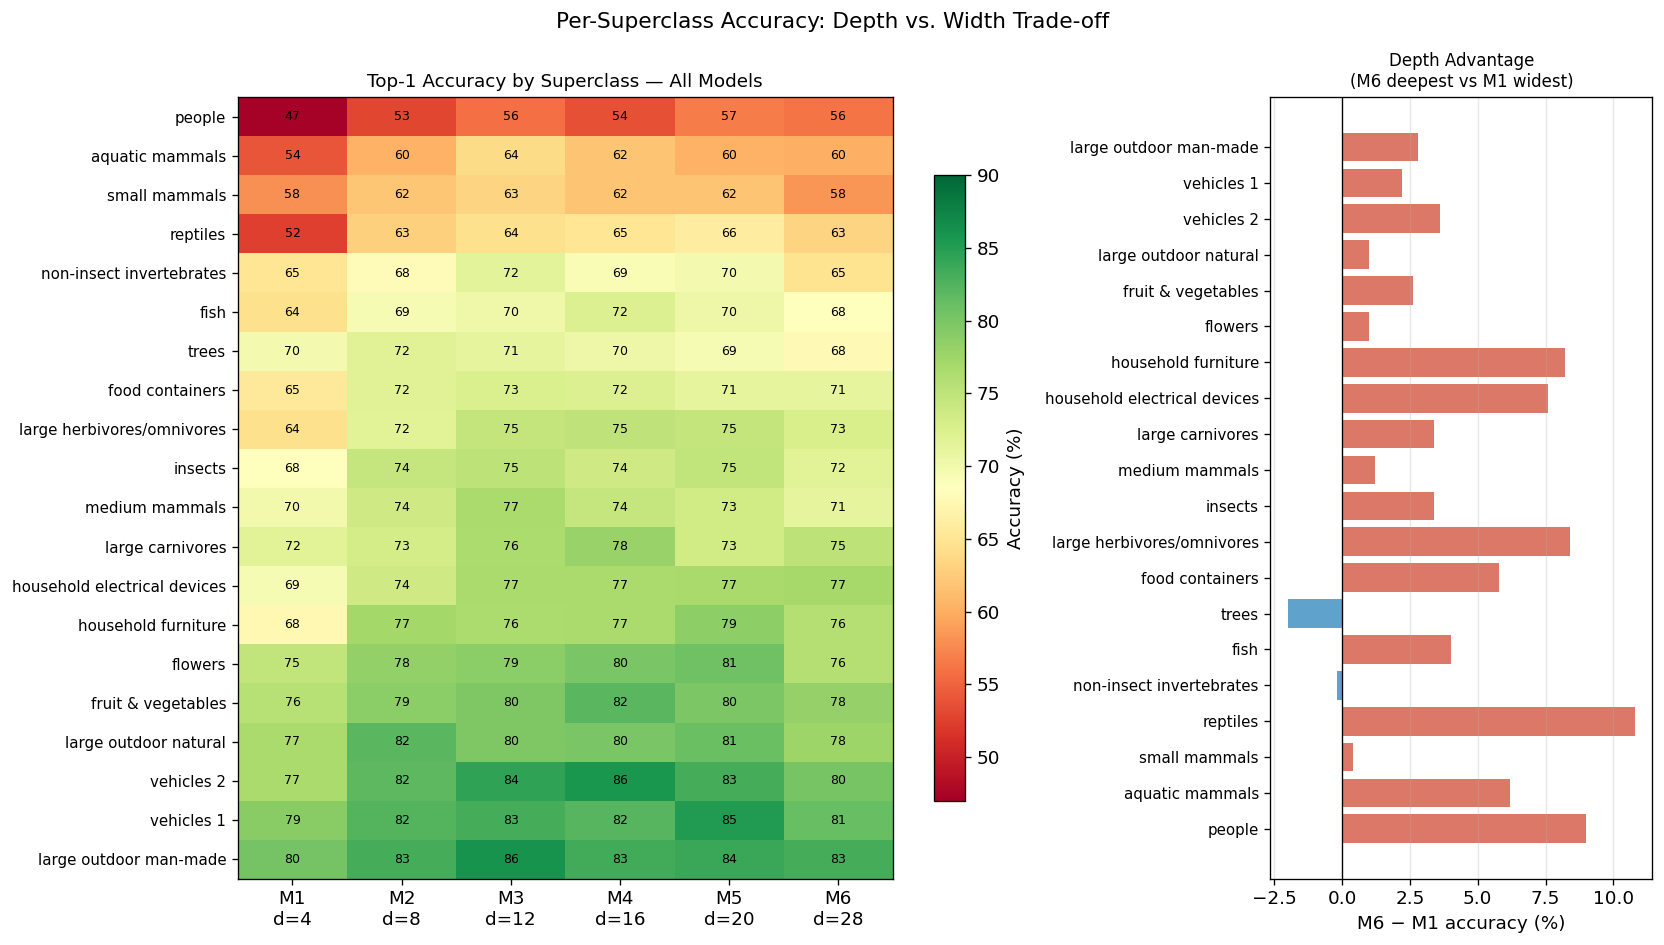

Saved: /content/drive/MyDrive/COMP5329_Deep_Learning_As2/figures/fig5_superclass_heatmap.pdf

>>> Phase 4 complete. All figures saved to Drive. <<<


In [13]:
# ── Figure 5: Superclass Accuracy Heatmap ────────────────────────────────────
superclasses = sorted(phase3['M1']['superclass_accuracy'].keys())
# Sort by average accuracy across all models (hardest at top)
avg_per_sup  = {s: np.mean([phase3[n]['superclass_accuracy'][s] for n in MODEL_NAMES])
                for s in superclasses}
superclasses = sorted(superclasses, key=lambda s: avg_per_sup[s])

data = np.array([[phase3[n]['superclass_accuracy'][s] for n in MODEL_NAMES]
                 for s in superclasses])

fig, axes = plt.subplots(1, 2, figsize=(14, 8),
                          gridspec_kw={'width_ratios': [3, 1.4]})

# Left: full heatmap (all 6 models)
im = axes[0].imshow(data, aspect='auto', cmap='RdYlGn', vmin=47, vmax=90)
axes[0].set_xticks(range(len(MODEL_NAMES)))
axes[0].set_xticklabels([f"{n}\nd={META[n]['depth']}" for n in MODEL_NAMES])
axes[0].set_yticks(range(len(superclasses)))
axes[0].set_yticklabels(superclasses, fontsize=9)
axes[0].set_title('Top-1 Accuracy by Superclass — All Models', fontsize=11)
plt.colorbar(im, ax=axes[0], label='Accuracy (%)', shrink=0.8)
for i in range(len(superclasses)):
    for j in range(len(MODEL_NAMES)):
        axes[0].text(j, i, f'{data[i,j]:.0f}', ha='center', va='center',
                     fontsize=7.5, color='black')

# Right: M6 − M1 depth advantage per superclass
diff = np.array([phase3['M6']['superclass_accuracy'][s] -
                 phase3['M1']['superclass_accuracy'][s] for s in superclasses])
bar_colors = ['#d6604d' if d > 0 else '#4393c3' for d in diff]
axes[1].barh(range(len(superclasses)), diff, color=bar_colors, alpha=0.85)
axes[1].set_yticks(range(len(superclasses)))
axes[1].set_yticklabels(superclasses, fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('M6 − M1 accuracy (%)')
axes[1].set_title('Depth Advantage\n(M6 deepest vs M1 widest)', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Per-Superclass Accuracy: Depth vs. Width Trade-off', fontsize=13)
plt.tight_layout()
path = os.path.join(FIGS_DIR, 'fig5_superclass_heatmap.pdf')
plt.savefig(path, bbox_inches='tight')
plt.savefig(path.replace('.pdf', '.png'), bbox_inches='tight')
plt.show()
print(f'Saved: {path}')
print('\n>>> Phase 4 complete. All figures saved to Drive. <<<')

---
## Smoke Test

Verifies the full pipeline (data → training → logging → Drive) works.
Run this after any large refactor to catch regressions early.

In [ ]:
# ── Smoke test: tiny MLP, 3 epochs ───────────────────────────────────────────
class _SmokeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 128), nn.ReLU(),
            nn.Linear(128, CFG['num_classes']),
        )
    def forward(self, x):
        return self.net(x)

_smoke = _SmokeMLP()
print(f'SmokeMLP params: {count_params(_smoke):,}')

_log, _best = train_model(_smoke, 'smoke_test', train_loader, test_loader, device,
                          cfg={**CFG, 'epochs': 3})

_csv = os.path.join(CFG['drive_base'], 'logs', 'smoke_test_log.csv')
assert os.path.exists(_csv), f'Log not found: {_csv}'
print(f'Log verified: {_csv}')
print('\n>>> SMOKE TEST PASSED <<<')